# Simulated Annealing Schedules

Michael Hahsler

In [1]:
import numpy as np
import matplotlib.pyplot as plt

%config InlineBackend.figure_format = 'retina'

## Cooling Schedules

### Exponential Schedule

See [1].

In [2]:
def temperature_exponential(time, initial_temperature, alpha):
    return initial_temperature * alpha**time

### Linear Schedule

See [1].

In [3]:
def temperature_linear(time, initial_temperature, eta):
    return initial_temperature - eta * time

### Fast Simulated Annealing

See [3].

In [4]:
def temperature_fast(time, initial_temperature):
    return initial_temperature / (1 + time)

### Logarithmic (Classic) Cooling

If $T_0$ is greater than or equal to the largest energy barrier in the problem, this schedule is guaranteed to find the global optimum in the limit of infinite time [2]. The schedule is defined for $t > 0$.

In [5]:
def temperature_logarithmic(time, initial_temperature):
    return initial_temperature / np.log1p(time)

## Comparison

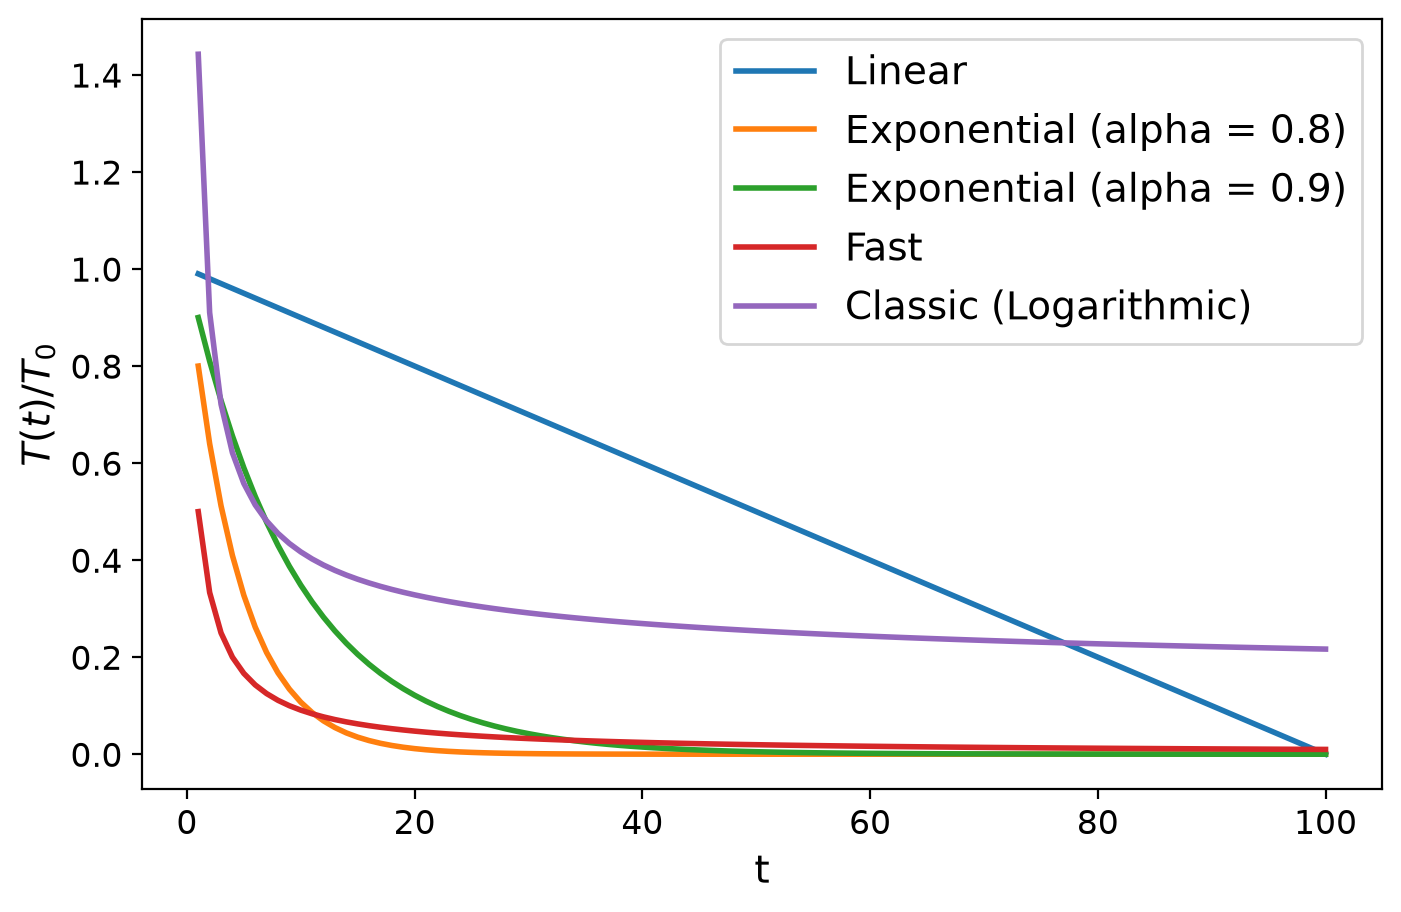

In [16]:
time = np.arange(1, 101)
initial_temperature = 1

schedules = {
    "Linear": temperature_linear(time, initial_temperature, eta=0.01),
    "Exponential (alpha = 0.8)": temperature_exponential(
        time, initial_temperature, alpha=0.8
    ),
    "Exponential (alpha = 0.9)": temperature_exponential(
        time, initial_temperature, alpha=0.9
    ),
    "Fast": temperature_fast(time, initial_temperature),
    "Classic (Logarithmic)": temperature_logarithmic(time, initial_temperature),
}

plt.figure(figsize=(8, 5))
for name, temperature in schedules.items():
    plt.plot(time, temperature / initial_temperature, label=name, linewidth=2)

plt.xlabel("t", fontsize=14)
plt.ylabel(r"$T(t) / T_0$", fontsize=14)

plt.legend()

plt.tick_params(axis='both', labelsize=12)
plt.legend(fontsize=14)
plt.show()

## Literature

1. Kirkpatrick, S., Gelatt, C. D. Jr., and Vecchi, M. P. (1983). Optimization by simulated annealing. *Science*, 220, 671–680.
2. Hajek, B. (1988). Cooling schedules for optimal annealing. *Mathematics of Operations Research*, 13, 311–329.
3. Szu, H., and Hartley, R. (1987). Fast simulated annealing. *Physics Letters A*, 122(3–4), 157–162. [doi:10.1016/0375-9601(87)90796-1](https://doi.org/10.1016/0375-9601(87)90796-1)